# **Insurance Premium Prediction**

## **WISIT SUWANNAO 67070501042**

---

## Overview

การทำนายเบี้ยประกันภัย (Insurance Premium Prediction) เป็นโจทย์สำคัญในธุรกิจประกันภัย เพื่อกำหนดราคาที่เหมาะสมและเป็นธรรมสำหรับลูกค้าแต่ละราย โดยวิเคราะห์จากปัจจัยเสี่ยงต่าง ๆ เช่น อายุ รายได้ สุขภาพ และประวัติการเคลม ข้อมูลที่แม่นยำจะช่วยให้บริษัทบริหารจัดการความเสี่ยงได้ดียิ่งขึ้น

## Dataset

Dataset ที่ใช้ในการแข่งขันนี้ประกอบด้วยข้อมูลลูกค้าและกรมธรรม์ประกันภัย โดยมีรายละเอียดดังนี้

| Column | Description |
|---|---|
| `Age` | อายุของผู้เอาประกันภัย |
| `Annual Income` | รายได้ต่อปี |
| `Marital Status` | สถานภาพการสมรส |
| `Number of Dependents` | จำนวนผู้อยู่ในอุปการะ |
| `Occupation` | อาชีพ |
| `Health Score` | คะแนนสุขภาพ (ยิ่งสูงยิ่งดี) |
| `Previous Claims` | จำนวนครั้งที่เคยเคลมประกันมาก่อน |
| `Vehicle Age` | อายุการใช้งานของยานพาหนะ |
| `Credit Score` | คะแนนเครดิตทางการเงิน |
| `Insurance Duration` | ระยะเวลาคุ้มครองของกรมธรรม์ (ปี) |
| `Policy Start Date` | วันที่เริ่มต้นกรมธรรม์ |
| `Customer Feedback` | ข้อเสนอแนะจากลูกค้า (Text) |
| `Premium Amount` | **Target Variable** — จำนวนเงินเบี้ยประกันภัย (MAE Metric) |

## Pipeline Architecture

1. **Exploratory Data Analysis (EDA)**
   วิเคราะห์การกระจายตัวของ Target (`Premium Amount`) และความสัมพันธ์ระหว่างตัวแปร (Correlation)

2. **Data Imputation & Feature Engineering**
   จัดการค่าสูญหาย (Imputation), แปลงวันที่ (`Policy Start Date`), สร้าง Feature ใหม่จาก Income/Health Interaction, และจัดกลุ่มลูกค้าด้วย **K-Means Clustering** เพื่อจับ Pattern ที่ซับซ้อน

3. **Ensemble Machine Learning (Stacking)**
   ฝึกโมเดล 4 ตัวด้วย **10-Fold Cross-Validation** ได้แก่ **XGBoost**, **LightGBM**, **CatBoost**, และ **LightGBM (Extra Trees)** เพื่อความแม่นยำสูงสุด

4. **Weight Optimization**
   นำ Out-of-Fold (OOF) Predictions มาหาค่าน้ำหนัก (Weights) ที่ทำให้ค่า MAE ต่ำที่สุด ด้วยเทคนิค `SLSQP Optimization` ก่อนนำไปทำนายผลลัพธ์จริง

## 1. Import Dependencies

นำเข้า Library ที่ใช้ในการวิเคราะห์ข้อมูล สร้างโมเดล และประเมินผล ได้แก่ `pandas` / `numpy` สำหรับ Data Manipulation, `matplotlib` / `seaborn` สำหรับ Visualization, `scikit-learn` สำหรับ Cross-Validation และ Model Evaluation, และ `xgboost` / `lightgbm` / `catboost` สำหรับ Gradient Boosting Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Data

โหลดไฟล์ `train.csv`, `test.csv` และ `sample_submission.csv` จาก Path ที่กำหนด โดย Script จะตรวจสอบ Path สำหรับการรันบน Kaggle โดยอัตโนมัติ

In [2]:
# Kaggle Paths
BASE_PATH = "/kaggle/input/competitions/cpe-232-insurance-premium-prediction"
train_path  = f"{BASE_PATH}/train.csv"
test_path   = f"{BASE_PATH}/test.csv"
sample_path = f"{BASE_PATH}/sample_submission.csv"

print(f"Loading data from: {train_path}")
import os

try:
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    sample_sub = pd.read_csv(sample_path)
    print(f"Train Shape: {train.shape}")
    print(f"Test Shape:  {test.shape}")
except FileNotFoundError:
    print("Files not found in Kaggle path. Checking local fallback for testing...")
    # Optional: Local fallback for development on your machine
    LOCAL_PATH = "cpe-232-insurance-premium-prediction"
    if os.path.exists(LOCAL_PATH):
        train = pd.read_csv(f"{LOCAL_PATH}/train.csv")
        test = pd.read_csv(f"{LOCAL_PATH}/test.csv")
        sample_sub = pd.read_csv(f"{LOCAL_PATH}/sample_submission.csv")
        print("Loaded from local path.")
    else:
        print("Please ensure the dataset is attached to the notebook.")

Loading data from: /kaggle/input/competitions/cpe-232-insurance-premium-prediction/train.csv
Train Shape: (520000, 20)
Test Shape:  (80000, 19)


## 3. Exploratory Data Analysis (EDA)

วิเคราะห์ข้อมูลเบื้องต้นเพื่อทำความเข้าใจโครงสร้างและปัญหาของ Dataset:
- **Target Distribution** — ตรวจสอบการกระจายตัวของ `Premium Amount`
- **Correlation Matrix** — วิเคราะห์ความสัมพันธ์ระหว่างตัวแปรตัวเลข

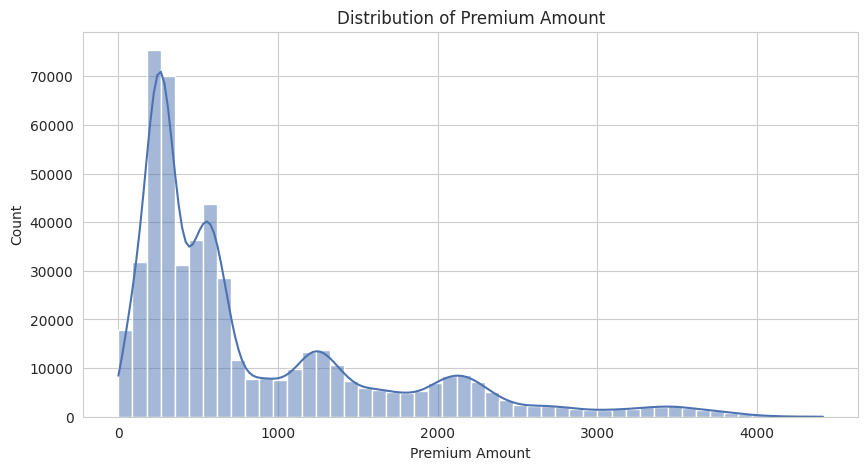

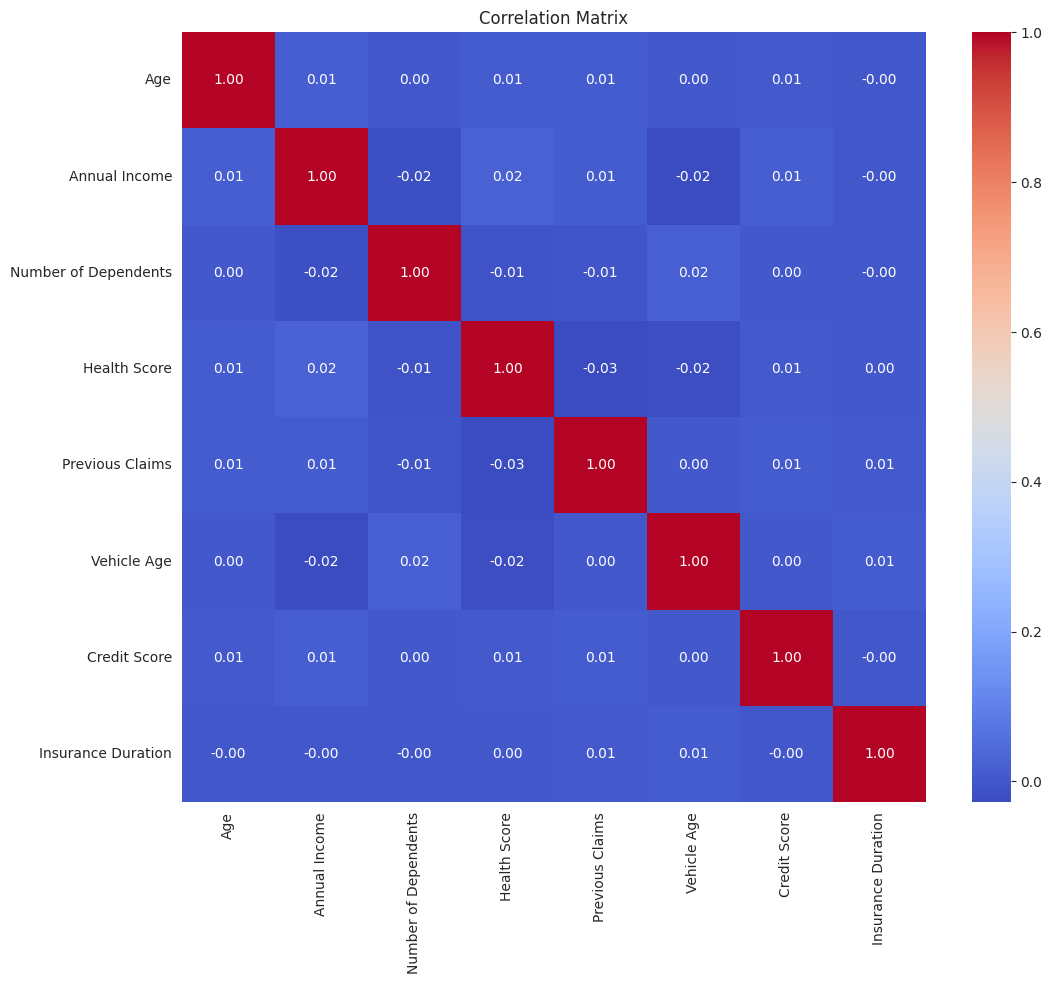

In [3]:
# Target Distribution
plt.figure(figsize=(10, 5))
sns.histplot(train['Premium Amount'], bins=50, kde=True, color='#4c72b0')
plt.title('Distribution of Premium Amount')
plt.show()

# Correlation Matrix (Numerical)
num_cols = train.select_dtypes(include=[np.number]).columns.drop(['id', 'Premium Amount'], errors='ignore')
corr = train[num_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 4. Feature Engineering

สร้าง Feature ใหม่จากความรู้เชิงโดเมน (Domain Knowledge) โดยใช้เทคนิคต่าง ๆ ดังนี้

- **Date Features** — แปลง `Policy Start Date` เป็น Year, Month, Day, DayOfWeek และคำนวณ `Policy_Age_Days`
- **Text Features** — นำความยาวข้อความจาก `Customer Feedback` มาเป็น Feature
- **Interaction Features** — สร้างตัวแปรใหม่จากการผสมผสาน เช่น `Income_Per_Dependent`, `Age_Health_Interaction`, `Claims_Density`
- **Binning** — จัดกลุ่ม `Age` เป็นช่วงอายุ (`Age_Group`) เพื่อลดความแปรปรวน
- **Log Transforms** — ใช้ `log1p()` กับ `Annual Income` เพื่อลด Skewness
- **K-Means Clustering** — ใช้ Unsupervised Learning จัดกลุ่มลูกค้าเป็น 6 Cluster
- **Imputation & Encoding** — เติมค่าสูญหายด้วย Median/Mode และทำ Label Encoding / Target Encoding สำหรับตัวแปรกลุ่ม

In [4]:
# Clean column names (remove leading/trailing spaces)
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

def preprocess_date(df):
    date_col = 'Policy Start Date'
    
    # Enhanced logic to find the date column
    if date_col not in df.columns:
        for col in df.columns:
            if 'Start Date' in col or 'start date' in col.lower(): 
                date_col = col
                break
    
    # SAFETY CHECK: If column still not found, return df to avoid KeyError
    if date_col not in df.columns:
        return df

    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['Policy_Year'] = df[date_col].dt.year
    df['Policy_Month'] = df[date_col].dt.month
    df['Policy_Day'] = df[date_col].dt.day
    df['Policy_DayOfWeek'] = df[date_col].dt.dayofweek
    
    ref_date = df[date_col].max()
    df['Policy_Age_Days'] = (ref_date - df[date_col]).dt.days
    
    return df

def feature_engineering(df):
    if 'Customer Feedback' in df.columns:
        df['Feedback_Len'] = df['Customer Feedback'].astype(str).apply(len)
        
    # --- Interaction Features  ---
    # Safe division helper
    def safe_div(a, b):
        return a / (b + 1e-6)

    if 'Annual Income' in df.columns and 'Number of Dependents' in df.columns:
        df['Income_Per_Dependent'] = safe_div(df['Annual Income'], df['Number of Dependents'])
        # Squared Income (for non-linear effects)
        df['Income_Squared'] = df['Annual Income'] ** 2
        
    if 'Age' in df.columns and 'Health Score' in df.columns:
        df['Age_Health_Interaction'] = df['Age'] * df['Health Score'] 
        df['Age_over_Health'] = safe_div(df['Age'], df['Health Score'])

    if 'Previous Claims' in df.columns and 'Vehicle Age' in df.columns:
        df['Claims_Density'] = safe_div(df['Previous Claims'], df['Vehicle Age'])
        
    # 3. Binning for Age
    if 'Age' in df.columns:
        df['Age_Group'] = pd.cut(df['Age'], bins=5, labels=False) 

    # 4. KMeans Clustering (Unsupervised Feature - "Customer Segment")
    # Using only numerical features available
    cluster_cols = ['Age', 'Annual Income', 'Health Score', 'Credit Score', 'Vehicle Age']
    available_cols = [c for c in cluster_cols if c in df.columns]
    
    if len(available_cols) >= 3:
        # Fill NA temporarily for clustering
        temp_data = df[available_cols].fillna(df[available_cols].median())
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(temp_data)
        
        # Reduced clusters to 6 for broader segments (less noise)
        kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
        df['Customer_Cluster'] = kmeans.fit_predict(scaled_data)

    # 5. Log Transform for Income (highly skewed)
    if 'Annual Income' in df.columns:
        df['Log_Annual_Income'] = np.log1p(df['Annual Income'])

    return df

print("Processing Features...")
train = preprocess_date(train)
test = preprocess_date(test)

train = feature_engineering(train)
test = feature_engineering(test)

# Drop Columns
drop_cols = ['id', 'Customer Feedback', 'Policy Start Date']
cols_to_drop = [c for c in drop_cols if c in train.columns]

X = train.drop(columns=['Premium Amount'] + cols_to_drop, errors='ignore')
y = train['Premium Amount']
X_test = test.drop(columns=cols_to_drop, errors='ignore')

# Imputation & Preprocessing
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# CLEANUP INF/NaN BEFORE IMPUTATION
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

if len(num_features) > 0:
    imputer_num = SimpleImputer(strategy='median')
    X[num_features] = imputer_num.fit_transform(X[num_features])
    X_test[num_features] = imputer_num.transform(X_test[num_features])

if len(cat_features) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X[cat_features] = imputer_cat.fit_transform(X[cat_features])
    X_test[cat_features] = imputer_cat.transform(X_test[cat_features])

# --- Robust Target Encoding ---
from sklearn.model_selection import KFold
print("Performing Robust Target Encoding...")
kf_encoding = KFold(n_splits=5, shuffle=True, random_state=42)

for col in cat_features:
    new_col_name = col + '_target_enc'
    X[new_col_name] = np.nan
    
    for train_idx, val_idx in kf_encoding.split(X, y):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        
        # Calculate mean on training fold
        temp_df = X_train_fold[[col]].copy()
        temp_df['target'] = y_train_fold
        target_mean = temp_df.groupby(col)['target'].mean()
        
        # Map to validation fold
        X.loc[val_idx, new_col_name] = X.iloc[val_idx][col].map(target_mean)
        
    global_mean = y.mean()
    X[new_col_name].fillna(global_mean, inplace=True)
    
    temp_full = X[[col]].copy()
    temp_full['target'] = y
    target_mean_full = temp_full.groupby(col)['target'].mean()
    X_test[new_col_name] = X_test[col].map(target_mean_full).fillna(global_mean)

# Label Encoding
for col in cat_features:
    le = LabelEncoder()
    full_data = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    le.fit(full_data)
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    
print("Preprocessing Complete.")

Processing Features...
Performing Robust Target Encoding...
Preprocessing Complete.


## 5. Model Training — XGBoost + LightGBM + CatBoost + Extra Trees

ฝึกโมเดล 4 ตัวแบบ Ensemble โดยใช้ **10-Fold Cross-Validation** เพื่อความแม่นยำสูงสุด และเก็บ Out-of-Fold (OOF) Predictions สำหรับขั้นตอน Weight Optimization

1. **XGBoost (Fast & Deep)** — Gradient Boosting ที่ปรับแต่งให้ลึกขึ้น (`max_depth=9`) และใช้ `reg:absoluteerror` เพื่อ Optimize MAE โดยตรง
2. **LightGBM (Standard)** — Decision Tree แบบ Leaf-wise ที่รวดเร็ว ใช้ `regression_l1` (L1/MAE Loss)
3. **CatBoost (High Precision)** — Gradient Boosting ที่จัดการ Categorical Data ได้ดีเยี่ยม ใช้ `loss_function='MAE'` และรันบน **GPU** (`task_type='GPU'`)
4. **LightGBM (Extra Trees)** — เพิ่มความหลากหลาย (Diversity) ให้กับ Ensemble โดยใช้ `extra_trees=True` ซึ่งจะสุ่มจุดตัดคล้าย Random Forest แต่ยังคงประสิทธิภาพแบบ Boosting

In [5]:
N_FOLDS = 10 
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Global placeholders
oof_preds_xgb = np.zeros(len(X))
test_preds_xgb = np.zeros(len(X_test))
oof_preds_lgb = np.zeros(len(X))
test_preds_lgb = np.zeros(len(X_test))
oof_preds_cat = np.zeros(len(X))
test_preds_cat = np.zeros(len(X_test))
oof_preds_rf = np.zeros(len(X))
test_preds_rf = np.zeros(len(X_test))

# --- 1. XGBoost (Fast & Deep) ---
print("\n========== Training XGBoost (Optimized) ==========")
xgb_params = {
    'n_estimators': 5000,           
    'learning_rate': 0.012,          # Optimal speed/accuracy
    'max_depth': 9,                 
    'min_child_weight': 40,         
    'subsample': 0.7,
    'colsample_bytree': 0.7,
    'objective': 'reg:absoluteerror', 
    'gamma': 0.2,                   
    'reg_alpha': 1.0,               
    'reg_lambda': 1.0,              
    'n_jobs': -1,
    'random_state': 42,
    'eval_metric': 'mae',
    'early_stopping_rounds': 300,
    'tree_method': 'hist', 
    'device': 'cuda' 
}
try:
    import torch
    if not torch.cuda.is_available(): xgb_params['device'] = 'cpu'
except: xgb_params['device'] = 'cpu'

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    oof_preds_xgb[val_idx] = model.predict(X_val)
    test_preds_xgb += model.predict(X_test) / N_FOLDS
    if fold % 2 == 0: print(f"Fold {fold+1} MAE: {mean_absolute_error(y_val, oof_preds_xgb[val_idx]):.4f}")

print(f"XGBoost Overall MAE: {mean_absolute_error(y, oof_preds_xgb):.4f}")

# --- 2. LightGBM (Standard) ---
print("\n========== Training LightGBM (Standard) ==========")
lgb_params = {
    'n_estimators': 5000,
    'learning_rate': 0.012,
    'num_leaves': 90,               
    'min_child_samples': 20,
    'objective': 'regression_l1',   
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.5,               
    'reg_lambda': 0.5               
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**lgb_params)
    
    callbacks = [lgb.early_stopping(stopping_rounds=300, verbose=False)]
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='mae', callbacks=callbacks)
    
    oof_preds_lgb[val_idx] = model.predict(X_val)
    test_preds_lgb += model.predict(X_test) / N_FOLDS
    if fold % 2 == 0: print(f"Fold {fold+1} MAE: {mean_absolute_error(y_val, oof_preds_lgb[val_idx]):.4f}")

print(f"LightGBM Overall MAE: {mean_absolute_error(y, oof_preds_lgb):.4f}")

# --- 3. CatBoost (High Precision) ---
print("\n========== Training CatBoost (MAE) ==========")
cat_params = {
    'iterations': 5000,
    'learning_rate': 0.012,
    'depth': 8,
    'l2_leaf_reg': 1,               
    'loss_function': 'MAE',
    'verbose': 0,
    'random_state': 42,
    'task_type': 'GPU',
    'devices': '0',
    'bootstrap_type': 'Bernoulli', 
    'subsample': 0.85
}
try:
    if not torch.cuda.is_available(): del cat_params['task_type']; del cat_params['devices']
except: pass

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostRegressor(**cat_params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=300)
    
    oof_preds_cat[val_idx] = model.predict(X_val)
    test_preds_cat += model.predict(X_test) / N_FOLDS
    if fold % 2 == 0: print(f"Fold {fold+1} MAE: {mean_absolute_error(y_val, oof_preds_cat[val_idx]):.4f}")

print(f"CatBoost Overall MAE: {mean_absolute_error(y, oof_preds_cat):.4f}")

# --- 4. LightGBM (Extra Trees) ---
print("\n========== Training LightGBM (Extra Trees) ==========")
lgb_xt_params = {
    'n_estimators': 5000,
    'learning_rate': 0.012,
    'num_leaves': 128,              
    'min_child_samples': 20,
    'objective': 'regression_l1',   
    'extra_trees': True,            
    'random_state': 2025,
    'n_jobs': -1,
    'verbose': -1,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**lgb_xt_params)
    
    callbacks = [lgb.early_stopping(stopping_rounds=300, verbose=False)]
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='mae', callbacks=callbacks)
    
    oof_preds_rf[val_idx] = model.predict(X_val) 
    test_preds_rf += model.predict(X_test) / N_FOLDS
    if fold % 2 == 0: print(f"Fold {fold+1} MAE: {mean_absolute_error(y_val, oof_preds_rf[val_idx]):.4f}")

print(f"LightGBM (Extra Trees) Overall MAE: {mean_absolute_error(y, oof_preds_rf):.4f}")


========== Training XGBoost (Optimized) ==========
Fold 1 MAE: 559.0259
Fold 3 MAE: 563.5943
Fold 5 MAE: 565.7563
Fold 7 MAE: 569.5048
Fold 9 MAE: 564.6856
XGBoost Overall MAE: 564.5822

========== Training LightGBM (Standard) ==========
Fold 1 MAE: 558.8237
Fold 3 MAE: 563.5043
Fold 5 MAE: 565.6217
Fold 7 MAE: 569.3482
Fold 9 MAE: 564.6742
LightGBM Overall MAE: 564.5127

========== Training CatBoost (MAE) ==========


Default metric period is 5 because MAE is/are not implemented for GPU


Fold 1 MAE: 562.5541


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


Fold 3 MAE: 567.5022


...

Fold 7 MAE: 572.8520


Default metric period is 5 because MAE is/are not implemented for GPU
Default metric period is 5 because MAE is/are not implemented for GPU


Fold 9 MAE: 568.6236


Default metric period is 5 because MAE is/are not implemented for GPU


CatBoost Overall MAE: 568.1795

========== Training LightGBM (Extra Trees) ==========
Fold 1 MAE: 559.1851
Fold 3 MAE: 563.8286
Fold 5 MAE: 566.0522
Fold 7 MAE: 569.6069
Fold 9 MAE: 564.9011
LightGBM (Extra Trees) Overall MAE: 564.8117


## 6. Ensemble & Submission

เราจะนำผลลัพธ์จากโมเดลทั้ง 4 ตัวมาหาค่าเฉลี่ยถ่วงน้ำหนัก (Weighted Average) โดยใช้วิธี **SLSQP Optimization** เพื่อคำนวณน้ำหนักที่ดีที่สุดที่ทำให้ MAE บนชุดข้อมูล Validation ต่ำที่สุด

$$ \text{FinalPred} = w_1 \cdot \text{XGB} + w_2 \cdot \text{LGB} + w_3 \cdot \text{Cat} + w_4 \cdot \text{XT} $$
โดยที่ $\sum w_i = 1$ และ $0 \le w_i \le 1$

In [6]:
print("Optimizing Weights (4 Models)...")
init_weights = [0.25, 0.25, 0.25, 0.25]
cons = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bounds = [(0.0, 1.0)] * 4

from scipy.optimize import minimize
def minimize_mae(weights):
    final_preds = (weights[0] * oof_preds_xgb) + (weights[1] * oof_preds_lgb) + (weights[2] * oof_preds_cat) + (weights[3] * oof_preds_rf)
    return mean_absolute_error(y, final_preds)

res = minimize(minimize_mae, init_weights, method='SLSQP', bounds=bounds, constraints=cons)
w_xgb, w_lgb, w_cat, w_rf = res.x

print(f"Optimized Weights -> XGB: {w_xgb:.4f}, LGB: {w_lgb:.4f}, Cat: {w_cat:.4f}, LGB_XT: {w_rf:.4f}")

final_oof_preds = (w_xgb * oof_preds_xgb) + (w_lgb * oof_preds_lgb) + (w_cat * oof_preds_cat) + (w_rf * oof_preds_rf)
ensemble_mae = mean_absolute_error(y, final_oof_preds)
print(f"Optimized Ensemble OOF MAE: {ensemble_mae:.4f}")

# Final Test Predictions
final_preds = (w_xgb * test_preds_xgb) + (w_lgb * test_preds_lgb) + (w_cat * test_preds_cat) + (w_rf * test_preds_rf)

submission = pd.DataFrame({
    'id': sample_sub['id'],
    'Premium Amount': final_preds
})

submission.to_csv('submission_IPP.csv', index=False)
print("Submission saved successfully.")
submission.head()

Optimizing Weights (4 Models)...
Optimized Weights -> XGB: 0.3649, LGB: 0.5894, Cat: 0.0000, LGB_XT: 0.0457
Optimized Ensemble OOF MAE: 564.4610
Submission saved successfully.


,id,Premium Amount
0,520001,627.725470
1,520002,480.738347
2,520003,504.708344
3,520004,568.366973
4,520005,374.300892
